# **Import Library**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings('ignore')

# **Load DataSet**

In [ ]:
df = pd.read_csv('/content/train.csv')
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# **Intro Data**

In [ ]:
df.shape

(891, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

,Survived,Age
0,0,424
1,1,290


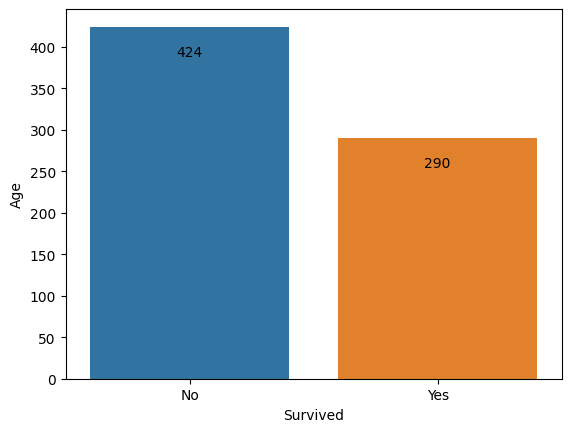

In [ ]:
Survival = df.groupby(['Survived'])['Age'].count().reset_index()
display(Survival)
sns.barplot(x=Survival['Survived'], y=Survival['Age'])
for i in Survival['Survived']:
    plt.text(i, Survival['Age'][i] - 35,Survival['Age'][i], ha='center')
plt.xticks([0,1], ['No', 'Yes'])
plt.show()

In [ ]:
df.dropna(subset = ['Age']).groupby('Survived')['Age'].mean()

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

,Survived,PassengerId
0,0,549
1,1,342


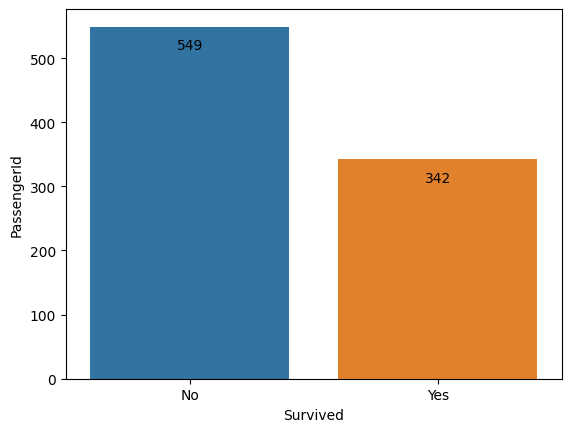

In [ ]:
Survival = df.groupby(['Survived'])['PassengerId'].count().reset_index()
display(Survival)
sns.barplot(x=Survival['Survived'], y=Survival['PassengerId'])
for i in Survival['Survived']:
    plt.text(i, Survival['PassengerId'][i] - 35,Survival['PassengerId'][i], ha='center')
plt.xticks([0,1], ['No', 'Yes'])
plt.show()

In [ ]:
df.dropna(subset = ['PassengerId']).groupby('Survived')['PassengerId'].mean()

Survived
0    447.016393
1    444.368421
Name: PassengerId, dtype: float64

,Survived,Embarked
0,0,549
1,1,340


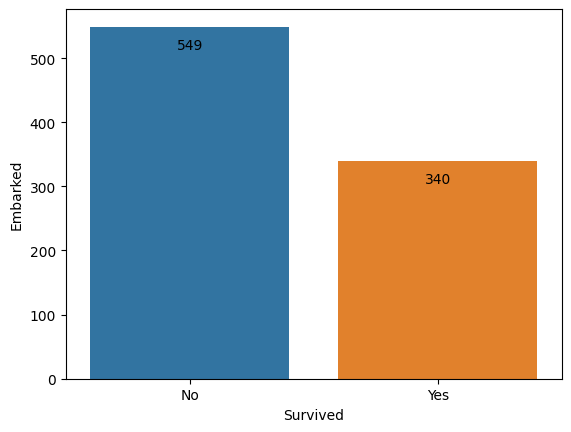

In [ ]:
Survival = df.groupby(['Survived'])['Embarked'].count().reset_index()
display(Survival)
sns.barplot(x=Survival['Survived'], y=Survival['Embarked'])
for i in Survival['Survived']:
    plt.text(i, Survival['Embarked'][i] - 35,Survival['Embarked'][i], ha='center')
plt.xticks([0,1], ['No', 'Yes'])
plt.show()

,Survived,Fare
0,0,549
1,1,342


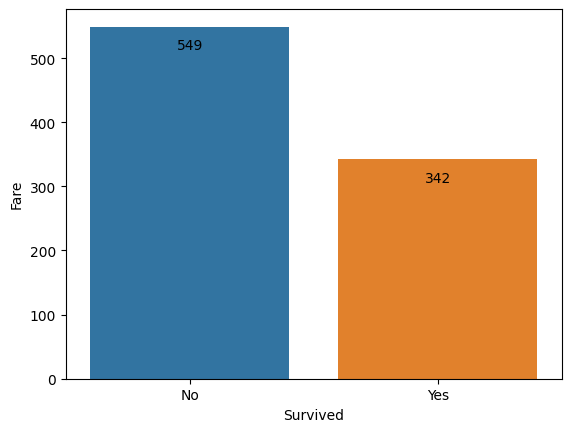

In [ ]:
Survival = df.groupby(['Survived'])['Fare'].count().reset_index()
display(Survival)
sns.barplot(x=Survival['Survived'], y=Survival['Fare'])
for i in Survival['Survived']:
    plt.text(i, Survival['Fare'][i] - 35,Survival['Fare'][i], ha='center')
plt.xticks([0,1], ['No', 'Yes'])
plt.show()

In [ ]:
#titanic_test = pd.read_csv('/kaggle/input/titanic/test.csv')
#titanic_test.head(5)

In [ ]:
#titanic_test.info()

In [ ]:
#titanic_test.describe()

In [ ]:
#titanic_test.describe()

In [ ]:
#titanic_test.columns

In [ ]:
survived_count=df.groupby('Survived')['Survived'].count()
survived_count

Survived
0    549
1    342
Name: Survived, dtype: int64

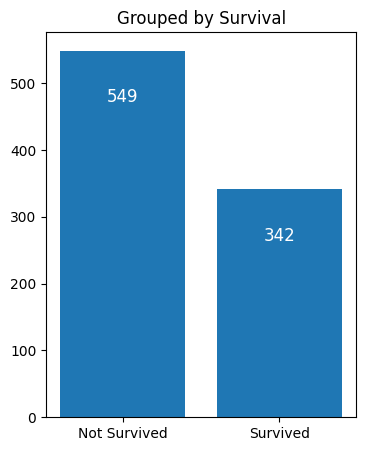

In [ ]:
plt.figure(figsize=(4,5))
plt.bar(survived_count.index, survived_count.values)
plt.title('Grouped by Survival')
plt.xticks([0,1], ['Not Survived', 'Survived'])

for i, value in enumerate(survived_count.values):
    plt.text(i, value-70, str(value), fontsize=12, color='white',
            horizontalalignment='center', verticalalignment='center')
plt.show()

In [ ]:
survived_sex = df[df['Survived']==1]['Sex'].value_counts()
survived_sex

female    233
male      109
Name: Sex, dtype: int64

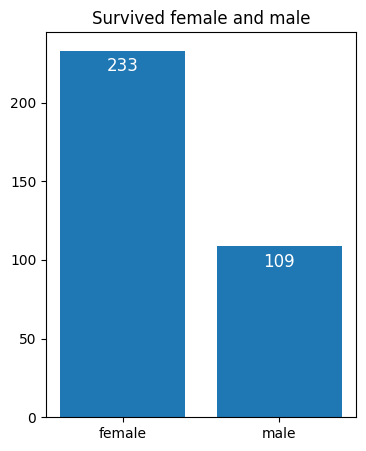

In [ ]:
#Visualisasi data jenis kelamin penumpang yang selamat

plt.figure(figsize=(4,5))
plt.bar(survived_sex.index, survived_sex.values)
plt.title('Survived female and male')

for i, value in enumerate(survived_sex.values):
    plt.text(i, value-10, str(value), fontsize=12, color='white',
            horizontalalignment='center', verticalalignment='center')
plt.show()

In [ ]:
pclass_count = df['Pclass'].value_counts()
pclass_count

3    491
1    216
2    184
Name: Pclass, dtype: int64

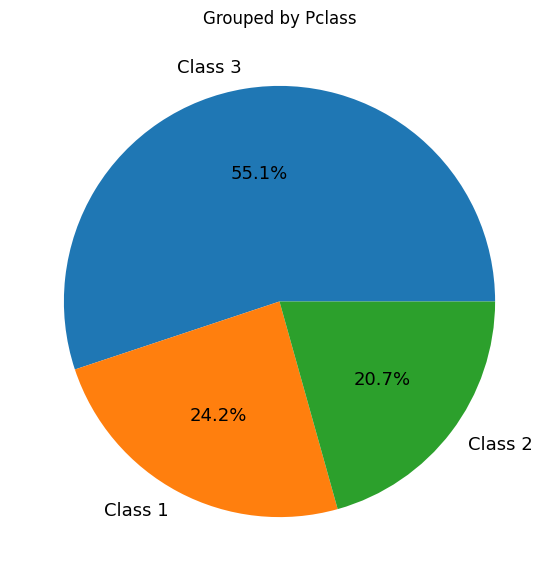

In [ ]:
plt.figure(figsize=(7,7))
plt.title('Grouped by Pclass')
plt.pie(pclass_count.values,
        labels=['Class {}'.format(i) for i in pclass_count.index],
        autopct='%1.1f%%', textprops={'fontsize':13})

plt.show()

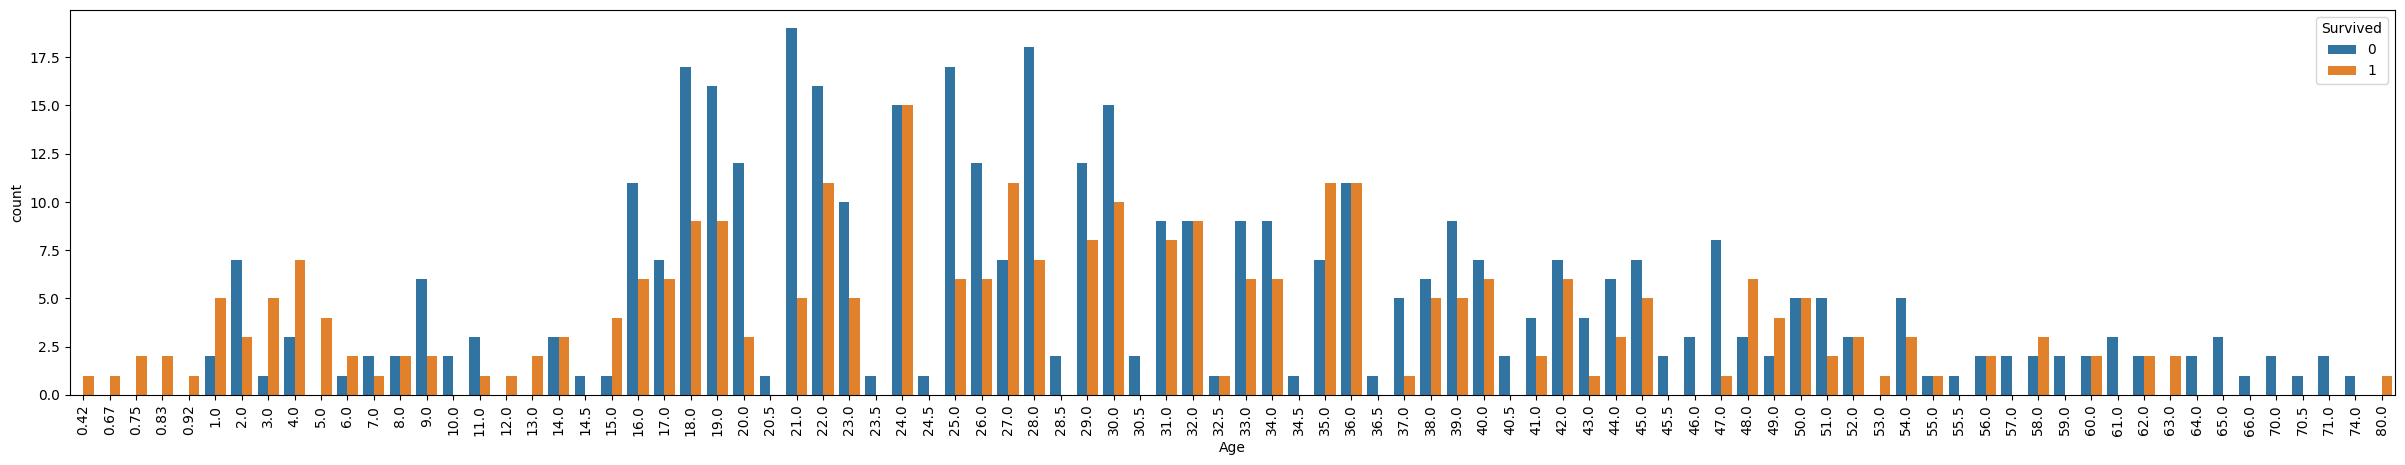

In [ ]:
plt.figure(figsize=(30,5))
sns.countplot(x = df['Age'], hue=df['Survived'])
plt.xticks(rotation=90)
plt.show()

In [ ]:
#get the age data which is NOT NaN

ages = df[df['Age'].notnull()]['Age'].values

#create the data for histogram
ages_hist = np.histogram(ages, bins=[0,10,20,30,40,50,60,70,80,90])
ages_hist

(array([ 62, 102, 220, 167,  89,  48,  19,   6,   1]),
 array([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90]))

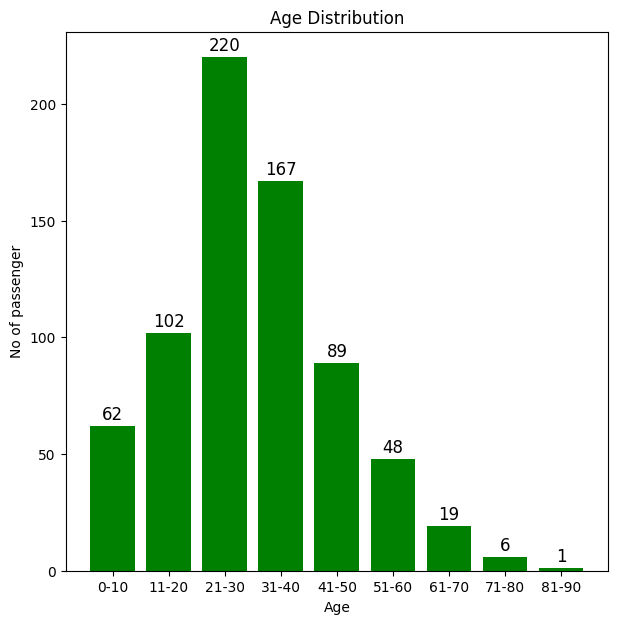

In [ ]:
# manual data labelling
ages_hist_labels = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90']

# create a histogram
plt.figure(figsize=(7,7))
plt.title('Age Distribution')
plt.bar(ages_hist_labels, ages_hist[0], color='Green')
plt.xlabel('Age')
plt.ylabel('No of passenger')

# add text to the bars
for i, bin in zip(ages_hist[0], range(9)):
    plt.text(bin, i+5, str(int(i)), fontsize=12, horizontalalignment='center', verticalalignment='center')

# show the plot
plt.show()

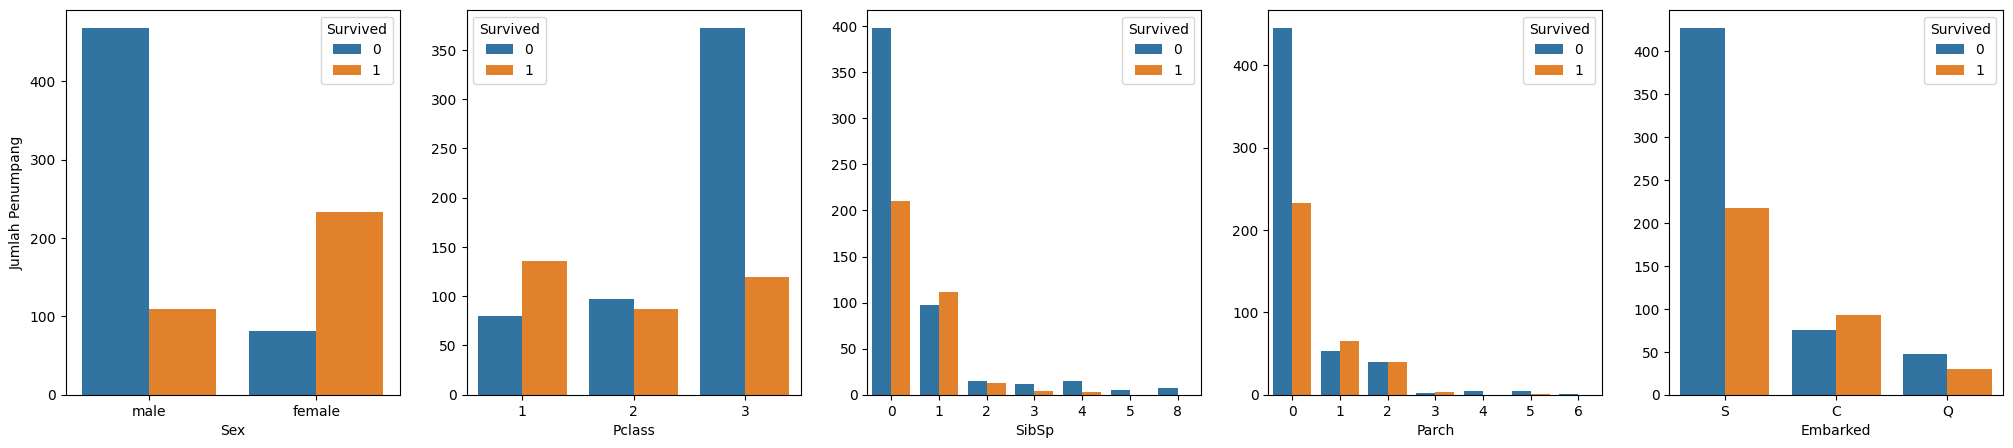

In [ ]:
list1 = ['Sex','Pclass', 'SibSp', 'Parch', 'Embarked']

fig, ax = plt.subplots(1,len(list1), figsize=(5*len(list1),5))
for i in range(0,len(list1)):
    sns.countplot(x=df[list1[i]], hue=df['Survived'], ax=ax[i])
    ax[i].set_ylabel('')
    ax[0].set_ylabel('Jumlah Penumpang')


# **Seleksi Data**

In [ ]:
mean_age = df['Age'].mean()
mean_fare = df['Fare'].mean()

df['Age'].fillna(mean_age, inplace=True)
df['Fare'].fillna(mean_fare, inplace=True)

In [ ]:
#melihat data UNIK pada fitur 'Cabin'
df['Cabin'].unique()[:10]

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78'], dtype=object)

In [ ]:
print('Training Data')
print('Sebelum dibersihkan:', df['Cabin'].shape)
cabins = df['Cabin'].dropna()

print("Setelah dibersihkan:", cabins.shape)
print()

#print('Testing Data')
#print('Sebelum dibersihkan:', titanic_test['Cabin'].shape)
#cabins_test = titanic_test['Cabin'].dropna()

#print("Setelah dibersihkan:", cabins_test.shape)

Training Data
Sebelum dibersihkan: (891,)
Setelah dibersihkan: (204,)



In [ ]:
def cabin_1(x):
    return x[0]

cabins = cabins.apply(cabin_1)
#cabins_test = cabins_test.apply(cabin_1)
print(cabins[:10])
#print(cabins_test[:10])

1     C
3     C
6     E
10    G
11    C
21    D
23    A
27    C
31    B
52    D
Name: Cabin, dtype: object


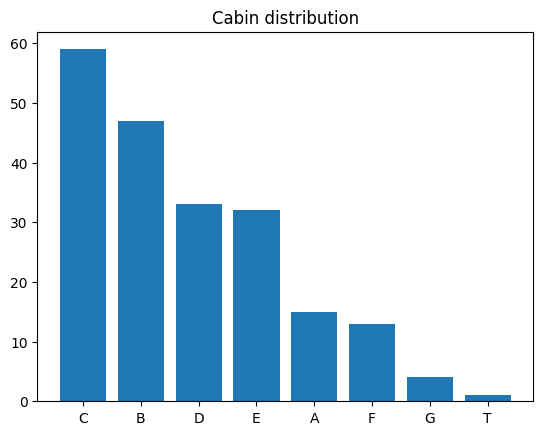

In [ ]:
cabins_count = cabins.value_counts()

plt.title('Cabin distribution')
plt.bar(cabins_count.index, cabins_count.values)
plt.show()

In [ ]:
df.groupby('Cabin')['Survived'].value_counts(normalize = True).mul(100).rename('Percentage').sort_index()


Cabin  Survived
A10    0           100.0
A14    0           100.0
A16    1           100.0
A19    0           100.0
A20    1           100.0
                   ...  
F38    0           100.0
F4     1           100.0
G6     0            50.0
       1            50.0
T      0           100.0
Name: Percentage, Length: 163, dtype: float64

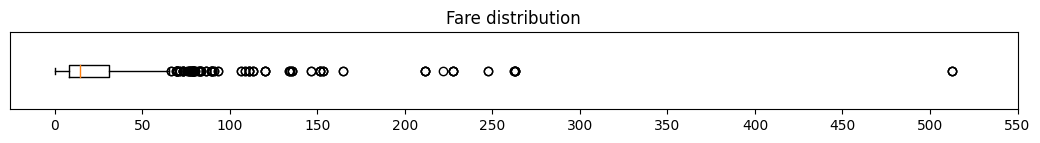

In [ ]:
#visualisasi jarak (FARE) penumpang

plt.figure(figsize=(13,1))
plt.title('Fare distribution')
plt.boxplot(df['Fare'], vert=False)
plt.yticks([])
plt.xticks(range(0,600,50))
plt.show()

In [ ]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [ ]:
#menggabungkan data keluarga menjadi 1 variabel 'Family Size'
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df[['Name','SibSp','Parch','FamilySize']]

,Name,SibSp,Parch,FamilySize
0,"Braund, Mr. Owen Harris",1,0,2
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0,2
2,"Heikkinen, Miss. Laina",0,0,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0,2
4,"Allen, Mr. William Henry",0,0,1
...,...,...,...,...
886,"Montvila, Rev. Juozas",0,0,1
887,"Graham, Miss. Margaret Edith",0,0,1
888,"Johnston, Miss. Catherine Helen ""Carrie""",1,2,4
889,"Behr, Mr. Karl Howell",0,0,1


In [ ]:
#titanic_test['FamilySize'] = titanic_test['SibSp'] + titanic_test['Parch'] + 1
#titanic_test[['Name','SibSp','Parch','FamilySize']]

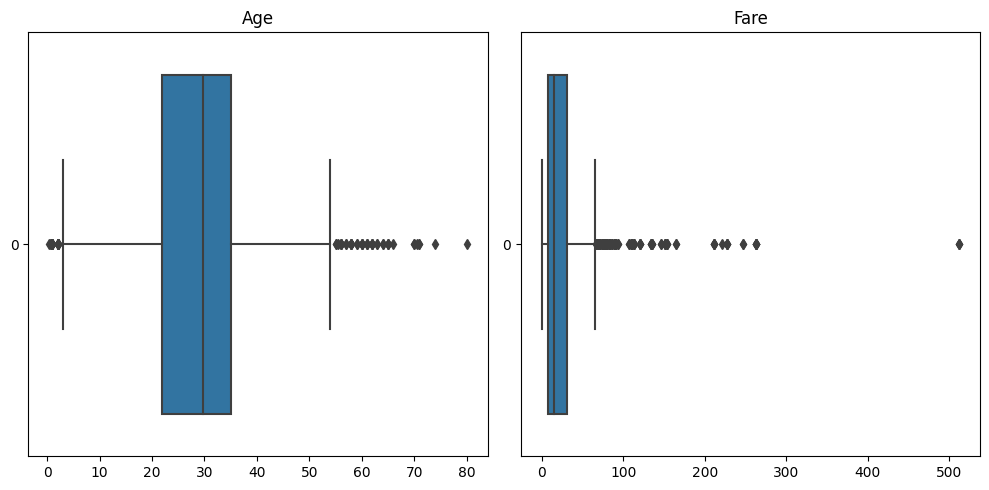

In [ ]:
list2 = ['Age', 'Fare']
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # Create a 1x2 grid of subplots

for i in range(len(list2)):
    sns.boxplot(df[list2[i]], orient='h', ax=axes[i])
    axes[i].set_title(list2[i])

plt.tight_layout()
plt.show()

In [ ]:
Q1 = df.Age.quantile(0.25)
Q3 = df.Age.quantile(0.75)
IQR = Q3 - Q1
df1 = df[~((df.Age < (Q1 - 1.5 * IQR)) | (df.Age > (Q3 +1.5 *IQR)))]
print(df.shape)
print(df1.shape)

(891, 13)
(825, 13)


In [ ]:
Q1 = df1.Fare.quantile(0.25)
Q3 = df1.Fare.quantile(0.75)
IQR = Q3 - Q1
df2 = df1[~((df1.Fare < (Q1 - 1.5 * IQR)) | (df1.Fare > (Q3 + 1.5 * IQR)))]
print(df1.shape)
print(df2.shape)

(825, 13)
(718, 13)


In [ ]:
df2

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S,1
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,NaN,Q,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,NaN,S,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,NaN,S,4
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C,1


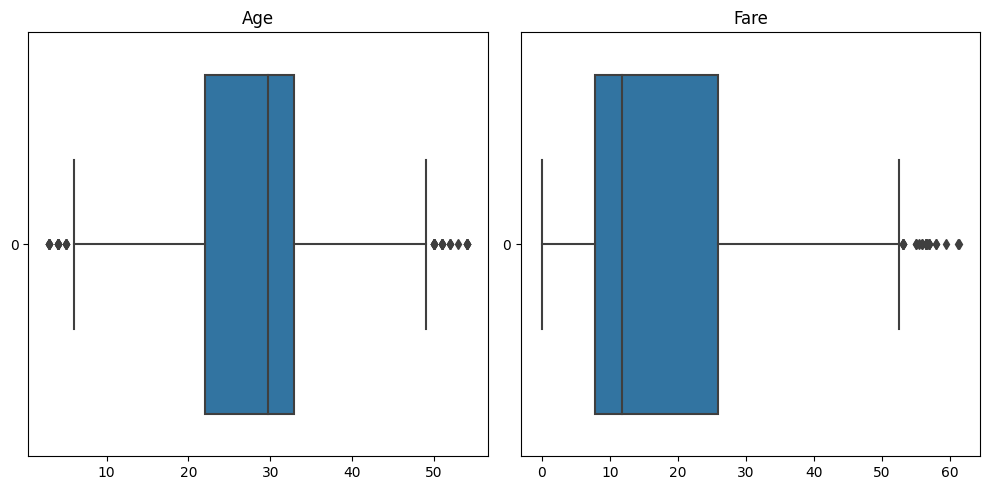

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

list2 = df2[['Age', 'Fare']]
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # Create a 1x2 grid of subplots

for i in range(len(list2.columns)):
    sns.boxplot(list2.iloc[:, i], orient='h', ax=axes[i])
    axes[i].set_title(list2.columns[i])

plt.tight_layout()
plt.show()


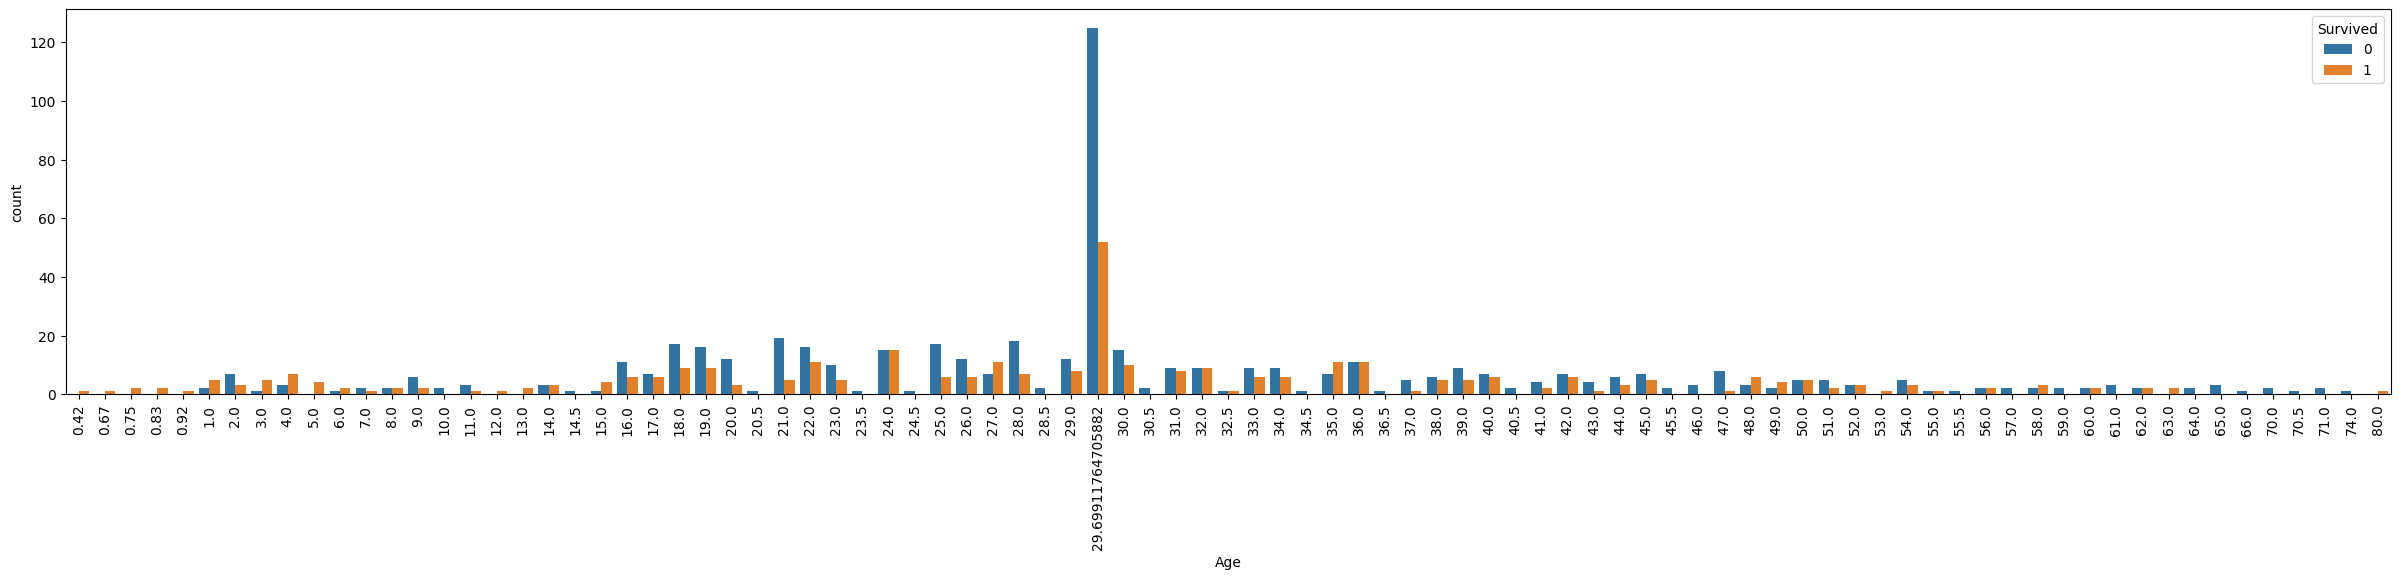

In [ ]:
plt.figure(figsize=(30,5))
sns.countplot(x = df['Age'], hue=df['Survived'])
plt.xticks(rotation=90)
plt.show()

In [ ]:
print('Training Data')
print('Sebelum drop :', df2.shape)
df3 = df2.dropna(subset=['Embarked'])
print('Setelah drop :', df1.shape)
print()

#print('Testing Data')
#print('Sebelum drop :', titanic_test.shape)
#titanic_test = titanic_test.dropna(subset=['Embarked'])
#print('Setelah drop :', titanic_test.shape)
#print()

Training Data
Sebelum drop : (718, 13)
Setelah drop : (825, 13)



In [ ]:
embarked_one_hot = pd.get_dummies(df3['Embarked'], prefix='Embarked')
df4 = pd.concat([df3, embarked_one_hot], axis=1)

In [ ]:
df4[['Name', 'Embarked', 'Embarked_C', 'Embarked_Q', 'Embarked_S']].head()

,Name,Embarked,Embarked_C,Embarked_Q,Embarked_S
0,"Braund, Mr. Owen Harris",S,0,0,1
2,"Heikkinen, Miss. Laina",S,0,0,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",S,0,0,1
4,"Allen, Mr. William Henry",S,0,0,1
5,"Moran, Mr. James",Q,0,1,0


In [ ]:
#test_embarked_one_hot = pd.get_dummies(titanic_test['Embarked'], prefix='Embarked')
#titanic_test = pd.concat([titanic_test, test_embarked_one_hot], axis=1)

In [ ]:
#titanic_test[['Name', 'Embarked', 'Embarked_C', 'Embarked_Q', 'Embarked_S']].head()

In [ ]:
#Hapus EMBARKED

titanic = df4.drop('Embarked', axis=1)
#titanic_test = titanic_test.drop('Embarked', axis=1)

In [ ]:
df4.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
2              3         1       3   
3              4         1       1   
4              5         0       3   
5              6         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                             Name     Sex        Age  SibSp  \
0                         Braund, Mr. Owen Harris    male  22.000000      1   
2                          Heikkinen, Miss. Laina  female  26.000000      0   
3    Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.000000      1   
4                        Allen, Mr. William Henry    male  35.000000      0   
5                                Moran, Mr. James    male  29.699118      0   
..                                   

In [ ]:
df4['Cabin'] = df4['Cabin'].fillna('U')
df4[['Name', 'Cabin']]

,Name,Cabin
0,"Braund, Mr. Owen Harris",U
2,"Heikkinen, Miss. Laina",U
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",C123
4,"Allen, Mr. William Henry",U
5,"Moran, Mr. James",U
...,...,...
886,"Montvila, Rev. Juozas",U
887,"Graham, Miss. Margaret Edith",B42
888,"Johnston, Miss. Catherine Helen ""Carrie""",U
889,"Behr, Mr. Karl Howell",C148


In [ ]:
#titanic_test['Cabin'] = titanic_test['Cabin'].fillna('U')
#titanic_test[['Name', 'Cabin']]

In [ ]:
def cabin_2(x):
    return x[0]

df4['Cabin'] = df4['Cabin'].apply(cabin_2)
print(df4[['Name', 'Cabin']])

#titanic_test['Cabin'] = titanic_test['Cabin'].apply(cabin_2)
#print(titanic_test[['Name', 'Cabin']])



                                             Name Cabin
0                         Braund, Mr. Owen Harris     U
2                          Heikkinen, Miss. Laina     U
3    Futrelle, Mrs. Jacques Heath (Lily May Peel)     C
4                        Allen, Mr. William Henry     U
5                                Moran, Mr. James     U
..                                            ...   ...
886                         Montvila, Rev. Juozas     U
887                  Graham, Miss. Margaret Edith     B
888      Johnston, Miss. Catherine Helen "Carrie"     U
889                         Behr, Mr. Karl Howell     C
890                           Dooley, Mr. Patrick     U

[718 rows x 2 columns]


In [ ]:
df4.Cabin.unique()

array(['U', 'C', 'E', 'G', 'D', 'A', 'F', 'B', 'T'], dtype=object)

In [ ]:
cabin_remap = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F":6, "G":7, "T":8, "U":9}
#test_cabin_remap = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F":6, "G":7, "T":8, "U":9}
df4['Cabin'] = df4['Cabin'].map(cabin_remap)
#titanic_test['Cabin'] = titanic_test['Cabin'].map(test_cabin_remap)

In [ ]:
print(df4['Cabin'])
#print(titanic_test['Cabin'])

0      9
2      9
3      3
4      9
5      9
      ..
886    9
887    2
888    9
889    3
890    9
Name: Cabin, Length: 718, dtype: int64


In [ ]:
#Ekstrak gelar pada nama

df4['gelar'] = df4.Name.str.extract('([A-Za-z]+)\.', expand = False)
#titanic_test['gelar'] = titanic_test.Name.str.extract('([A-Za-z]+)\.', expand = False)
df4.drop('Name', axis = 1, inplace = True)
#titanic_test.drop('Name', axis = 1, inplace = True)

print(df4.gelar.value_counts())
#print(titanic_test.gelar.value_counts())

Mr          452
Miss        132
Mrs          93
Master       23
Rev           5
Dr            5
Major         2
Don           1
Ms            1
Lady          1
Sir           1
Mlle          1
Jonkheer      1
Name: gelar, dtype: int64


In [ ]:
#pengelompokan gelar yang langka
unimportant = [ 'Dr', 'Rev', 'Major', 'Col', 'Mlle',
       'Jonkheer', 'Mme', 'Lady', 'Capt', 'Don', 'Sir', 'the Countess','Ms']

df4.gelar = df4.gelar.replace(unimportant, 'Rare')
#titanic_test.gelar = titanic_test.gelar.replace(unimportant, 'Rare')

In [ ]:
#konversi gelar ke bentuk integer
gelar_remap = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
df4['gelar'] = df4['gelar'].map(gelar_remap)

#test_title_remap = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
#titanic_test['gelar'] = titanic_test['gelar'].map(test_title_remap)

In [ ]:
sex_one_hot = pd.get_dummies(df4['Sex'], prefix='Sex')
df4 = pd.concat([df4, sex_one_hot], axis=1)

#remove initial sex column
df5 = df4.drop('Sex', axis=1)

df5.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked', 'FamilySize', 'Embarked_C', 'Embarked_Q',
       'Embarked_S', 'gelar', 'Sex_female', 'Sex_male'],
      dtype='object')

In [ ]:
#test_sex_one_hot = pd.get_dummies(titanic_test['Sex'], prefix='Sex')
#titanic_test = pd.concat([titanic_test, test_sex_one_hot], axis=1)

#remove initial sex column
#titanic_test = titanic_test.drop('Sex', axis=1)

#titanic_test.columns

In [ ]:
df6 = df5.drop(['PassengerId', 'Ticket', 'gelar','Embarked'], axis=1)
#titanic_test = titanic_test.drop(['PassengerId', 'Ticket', 'gelar'], axis=1)

In [ ]:
df5

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,Embarked_C,Embarked_Q,Embarked_S,gelar,Sex_female,Sex_male
0,1,0,3,22.000000,1,0,A/5 21171,7.2500,9,S,2,0,0,1,1,0,1
2,3,1,3,26.000000,0,0,STON/O2. 3101282,7.9250,9,S,1,0,0,1,2,1,0
3,4,1,1,35.000000,1,0,113803,53.1000,3,S,2,0,0,1,3,1,0
4,5,0,3,35.000000,0,0,373450,8.0500,9,S,1,0,0,1,1,0,1
5,6,0,3,29.699118,0,0,330877,8.4583,9,Q,1,0,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.000000,0,0,211536,13.0000,9,S,1,0,0,1,5,0,1
887,888,1,1,19.000000,0,0,112053,30.0000,2,S,1,0,0,1,2,1,0
888,889,0,3,29.699118,1,2,W./C. 6607,23.4500,9,S,4,0,0,1,2,1,0
889,890,1,1,26.000000,0,0,111369,30.0000,3,C,1,1,0,0,1,0,1


In [ ]:
df6

,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,FamilySize,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male
0,0,3,22.000000,1,0,7.2500,9,2,0,0,1,0,1
2,1,3,26.000000,0,0,7.9250,9,1,0,0,1,1,0
3,1,1,35.000000,1,0,53.1000,3,2,0,0,1,1,0
4,0,3,35.000000,0,0,8.0500,9,1,0,0,1,0,1
5,0,3,29.699118,0,0,8.4583,9,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,9,1,0,0,1,0,1
887,1,1,19.000000,0,0,30.0000,2,1,0,0,1,1,0
888,0,3,29.699118,1,2,23.4500,9,4,0,0,1,1,0
889,1,1,26.000000,0,0,30.0000,3,1,1,0,0,0,1


# **Normalisasi Data**

In [ ]:
sc = StandardScaler()
df6.iloc[:, 1:] = sc.fit_transform(df6.iloc[:, 1:])

In [ ]:
df6

,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,FamilySize,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male
0,0,0.681465,-0.644501,0.686268,-0.404910,-0.751265,0.373390,0.196534,-0.411559,-0.331266,0.567700,-0.684326,0.684326
2,1,0.681465,-0.245599,-0.484137,-0.404910,-0.700265,0.373390,-0.534613,-0.411559,-0.331266,0.567700,1.461291,-1.461291
3,1,-2.114490,0.651930,0.686268,-0.404910,2.712961,-2.837314,0.196534,-0.411559,-0.331266,0.567700,1.461291,-1.461291
4,0,0.681465,0.651930,-0.484137,-0.404910,-0.690821,0.373390,-0.534613,-0.411559,-0.331266,0.567700,-0.684326,0.684326
5,0,0.681465,0.123297,-0.484137,-0.404910,-0.659971,0.373390,-0.534613,-0.411559,3.018721,-1.761493,-0.684326,0.684326
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,-0.716512,-0.145874,-0.484137,-0.404910,-0.316820,0.373390,-0.534613,-0.411559,-0.331266,0.567700,-0.684326,0.684326
887,1,-2.114490,-0.943677,-0.484137,-0.404910,0.967626,-3.372431,-0.534613,-0.411559,-0.331266,0.567700,1.461291,-1.461291
888,0,0.681465,0.123297,0.686268,2.145313,0.472736,0.373390,1.658828,-0.411559,-0.331266,0.567700,1.461291,-1.461291
889,1,-2.114490,-0.245599,-0.484137,-0.404910,0.967626,-2.837314,-0.534613,2.429783,-0.331266,-1.761493,-0.684326,0.684326


In [ ]:
#sc = StandardScaler()
#df4.iloc[:, 1:] = sc.fit_transform(df4.iloc[:, 1:])

# **KNN Model**

In [ ]:
X = df6.iloc[:, 1:].values
y = df6.iloc[:, 0].values

In [ ]:
# Splitting into the training set and test setfrom sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
classifier1 = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
classifier1.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
# Evaluasi
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = classifier1.predict(X_test)
cm1 = confusion_matrix(y_test, y_pred1)
print(cm1)
accuracy_score(y_test, y_pred)*100

[[96 18]
 [25 41]]


0.7611111111111111

In [ ]:
# Perbandingan Data Asli dan Hasil Prediksi
print(np.concatenate((y_test.reshape(len(y_test), 1), y_pred1.reshape(len(y_pred1), 1)), 1))

[[0 0]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [0 1]
 [1 0]
 [0 0]
 [0 1]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [1 0]
 [1 1]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 0]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [1 1]
 [0 1]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 0]
 [1 0]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [1 0]
 [0 1]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 0]

# **LR Model**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
X1 = df6.iloc[:, 1:].values
Y1 = df6.iloc[:, 0].values
X1_train, X1_test, Y1_train, Y1_test = train_test_split(X1,Y1,test_size = 0.3,random_state = 789)
lr = LogisticRegression(random_state=0)
l = lr.fit(X1_train,Y1_train)
l.score(X1_train,Y1_train)*100

82.27091633466136

In [ ]:
Y1_pred = lr.predict(X1_test)
accuracy_score(Y1_test, Y1_pred)*100

75.46296296296296

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print('\nconfusion matrix')
print(confusion_matrix(Y1_test, Y1_pred))
print('\naccuracy')
print(accuracy_score(Y1_test, Y1_pred)*100)
print('\nclassification report')
print(classification_report(Y1_test, Y1_pred))


confusion matrix
[[109  19]
 [ 34  54]]

accuracy
75.46296296296296

classification report
              precision    recall  f1-score   support

           0       0.76      0.85      0.80       128
           1       0.74      0.61      0.67        88

    accuracy                           0.75       216
   macro avg       0.75      0.73      0.74       216
weighted avg       0.75      0.75      0.75       216



In [ ]:
pred_arr = np.concatenate((_test.reshape(len(y_test), 1), y_pred.reshape(len(y_pred), 1)), 1)
print(pred_arr)

[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 1]
 [0 1]
 [0 0]
 [0 0]
 [1 0]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 1]
 [1 0]
 [0 0]
 [0 1]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 0]
 [1 0]
 [0 0]
 [0 0]
 [1 0]
 [0 1]
 [0 0]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 1]
 [1 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [0 1]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 0]

In [ ]:
pred_arr.shape

(144, 2)

In [ ]:
pred_df = pd.DataFrame({'Actual Value': y_test, 'Predicted Value': y_pred})
pred_df

,Actual Value,Predicted Value
0,0,0
1,0,0
2,0,0
3,0,0
4,1,1
...,...,...
139,0,0
140,0,0
141,0,0
142,1,0


In [ ]:
# Menghitung jumlah data yang berbeda antara kolom "Actual Value" dan "Predicted Value"
different_values_count = (pred_df['Actual Value'] != pred_df['Predicted Value']).sum()

print("Jumlah data di mana 'Actual Value' berbeda dari 'Predicted Value':", different_values_count)


Jumlah data di mana 'Actual Value' berbeda dari 'Predicted Value': 28


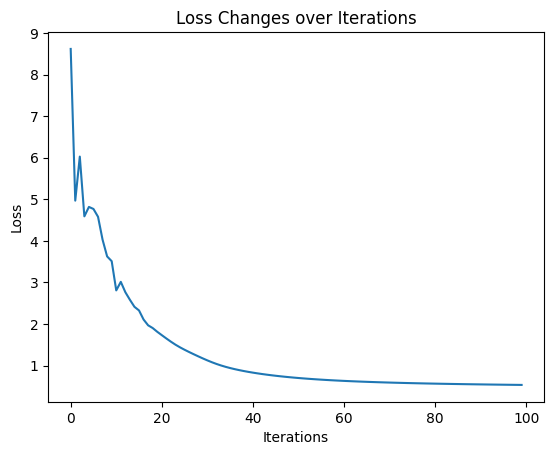

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss  # Mengimpor log_loss
import matplotlib.pyplot as plt
import numpy as np

# Inisialisasi model SGDClassifier (logistic regression)
sgd = SGDClassifier(loss='log', max_iter=100, random_state=42)

# Menyiapkan list untuk menyimpan loss pada setiap iterasi
losses = []

# Pelatihan model dan mengukur loss pada setiap iterasi
for iteration in range(100):  # Anda dapat menyesuaikan jumlah iterasi sesuai kebutuhan
    sgd.partial_fit(X, Y, classes=[0, 1])
    loss = log_loss(Y, sgd.predict_proba(X)[:, 1])
    losses.append(loss)

# Menampilkan grafik perubahan loss
plt.plot(losses)
plt.ylabel('Loss')
plt.xlabel('Iterations')
plt.title('Loss Changes over Iterations')
plt.show()

# **MLPClassifier**

In [ ]:
X2 = df6.iloc[:, 1:].values
y2 = df6.iloc[:, 0].values

In [ ]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2,y2,test_size = 0.30)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X2_train)

StandardScaler()

In [ ]:
X2_train = scaler.transform(X2_train)
X2_test = scaler.transform(X2_test)

In [ ]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(10,10,10), max_iter=1000)

In [ ]:
mlp.fit(X2_train, y2_train)

MLPClassifier(hidden_layer_sizes=(10, 10, 10), max_iter=1000)

In [ ]:
predic = mlp.predict(X2_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y2_test, predic)
print('Accuracy: ',accuracy *100)

Accuracy:  81.01851851851852


In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y2_test,predic))

[[130  21]
 [ 20  45]]


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y2_test,predic))

              precision    recall  f1-score   support

           0       0.79      0.91      0.85       139
           1       0.79      0.57      0.66        77

    accuracy                           0.79       216
   macro avg       0.79      0.74      0.76       216
weighted avg       0.79      0.79      0.78       216



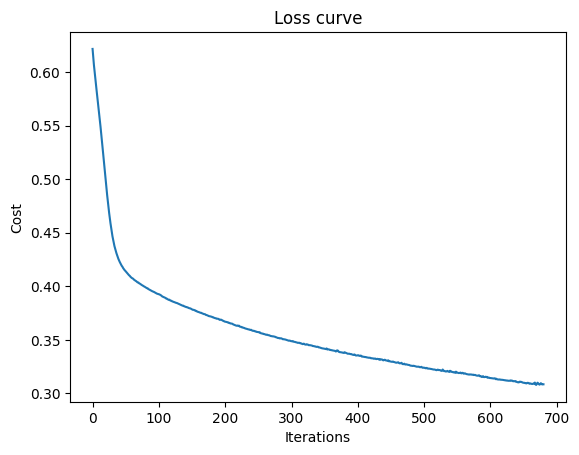

In [ ]:
plt.plot(mlp.loss_curve_)
plt.ylabel('Cost')
plt.xlabel('Iterations')
plt.title('Loss curve')
plt.show()